# Static–dynamic reliability across frame timings

This notebook reads only the saved NPZ result files. It does not load the original static or dynamic raster MAT files. For every frame timing, it visualizes raw and RSA self-consistency together with all-trial and half-trial static–dynamic cross-temporal correlations.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config.yaml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find config.yaml above the notebook directory.")
    # end if PROJECT_ROOT.parent == PROJECT_ROOT
    PROJECT_ROOT = PROJECT_ROOT.parent
# end while not config.yaml exists
sys.path.append(str(PROJECT_ROOT / "python_scripts" / "src"))

from project_specific_utils import split_half_filename_suffix


@dataclass
class Cfg:
    static_exp_name: str = "red_20260726to27" # "baby1_260718to27" # 
    dynamic_exp_name: str = "red_20260720to24" # "baby1_260716to24" #
    results_dir: str | None = None
    # Set both to None for all channels; otherwise choose one selection mode.
    good_channels: tuple[int, int] | None = None #(101,109) # e.g. (101, 109)
    top_k: int | None = None  # e.g. 50
    frame_timings: tuple[str, ...] = ("last_frame", "2000ms", "2250ms")
    use_spearman_brown: bool = True
    feature_centering: bool = True
    rdm_metric: str = "cosine_cnt"
    static_reference_window_ms: tuple[float, float] = (0, 1000)
    matrix_vmin: float = 0
    matrix_vmax: float = 1
    plot_smoothing_sigma: float = 2  # Set to 0 to disable line smoothing.



def channel_selection_name(cfg):
    """Return the result-directory label for the selected channels."""
    if cfg.good_channels is not None:
        first_channel, last_channel = cfg.good_channels
        return f"channels_{first_channel}to{last_channel}"
    # end if cfg.good_channels
    if cfg.top_k is not None:
        return f"top_{cfg.top_k}"
    # end if cfg.top_k
    return "all_channels"
# EOF


cfg = Cfg()
if cfg.good_channels is not None and cfg.top_k is not None:
    raise ValueError("Set either good_channels or top_k, not both.")
# end if channel selection
filename_suffix = split_half_filename_suffix(
    cfg.rdm_metric, cfg.feature_centering,
)
results_root = Path(
    cfg.results_dir
    or PROJECT_ROOT
    / "results"
    / "static_dynamic_all_frame_timings"
    / f"{cfg.dynamic_exp_name}_vs_{cfg.static_exp_name}"
).expanduser()
channel_results_dir = results_root / channel_selection_name(cfg)
if channel_results_dir.is_dir():
    results_dir = channel_results_dir
elif (results_root / f"config{filename_suffix}.json").is_file():
    # Compatibility with results generated before channel-specific folders.
    results_dir = results_root
    print(f"Using legacy result directory without channel label: {results_root}")
else:
    results_dir = channel_results_dir
# end if channel_results_dir
cfg, results_dir

(Cfg(static_exp_name='red_20260726to27', dynamic_exp_name='red_20260720to24', results_dir=None, good_channels=None, top_k=None, frame_timings=('last_frame', '2000ms', '2250ms'), use_spearman_brown=True, feature_centering=True, rdm_metric='cosine_cnt', static_reference_window_ms=(0, 1000), matrix_vmin=0, matrix_vmax=1, plot_smoothing_sigma=2),
 PosixPath('/Users/tizianocausin/Desktop/static_dynamic/results/static_dynamic_all_frame_timings/red_20260720to24_vs_red_20260726to27/all_channels'))

## Load saved results

Each archive contains the time axes, trial counts, uncorrected split values, mean/SD/interval reliability summaries, and the full- and half-movie-trial cross-temporal matrices. Raw results also retain the SD across matched stimulus correlations.

In [2]:
results_by_timing = {}
for frame_timing in cfg.frame_timings:
    result_path = results_dir / f"{frame_timing}{filename_suffix}_results.npz"
    if not result_path.is_file():
        raise FileNotFoundError(f"Missing result file: {result_path}")
    # end if result_path
    with np.load(result_path, allow_pickle=False) as archive:
        results_by_timing[frame_timing] = {
            result_name: archive[result_name]
            for result_name in archive.files
        }
    # end with np.load
    saved_rdm_metric = str(
        results_by_timing[frame_timing]["rdm_metric"].item()
    )
    if saved_rdm_metric != cfg.rdm_metric:
        raise ValueError(
            f"Expected RDM metric {cfg.rdm_metric!r}, but {result_path} "
            f"contains {saved_rdm_metric!r}."
        )
    # end if saved_rdm_metric
# end for frame_timing

for frame_timing, results in results_by_timing.items():
    print(
        f"{frame_timing}: {len(results['shared_stimuli'])} stimuli, "
        f"{len(results['channel_numbers'])} channels, "
        f"{results['raw_lagged_correlation_half_dynamic_trials'].shape[0]} "
        "half-trial repeats"
    )
# end for frame_timing

last_frame: 100 stimuli, 64 channels, 10 half-trial repeats
2000ms: 100 stimuli, 64 channels, 10 half-trial repeats
2250ms: 100 stimuli, 64 channels, 10 half-trial repeats


In [3]:
print(result_path)

/Users/tizianocausin/Desktop/static_dynamic/results/static_dynamic_all_frame_timings/red_20260720to24_vs_red_20260726to27/all_channels/2250ms_rdm_cosine_cnt_feat_cnt_results.npz


## Numerical helpers

In [4]:
"""
get_self_consistency_summary
Select the saved uncorrected or Spearman–Brown reliability summary.

INPUT:
    - results: dict[str, np.ndarray] -> one frame timing's saved arrays
    - condition: str -> static or dynamic
    - analysis_type: str -> raw or rsa
    - use_spearman_brown: bool -> select corrected or uncorrected arrays

OUTPUT:
    - summary: dict[str, np.ndarray] -> mean/lower/upper and optional SD timecourses
"""
def get_self_consistency_summary(
        results, condition, analysis_type, use_spearman_brown,
        ):
    suffix = "spearman_brown" if use_spearman_brown else "uncorrected"
    prefix = f"{condition}_{analysis_type}_self_consistency"
    summary = {
        statistic: results[f"{prefix}_{statistic}_{suffix}"]
        for statistic in ("mean", "lower", "upper")
    }
    std_key = f"{prefix}_std_{suffix}"
    if std_key in results:
        summary["std"] = results[std_key]
    # end if std_key
    return summary
# EOF


"""
best_static_fit
Select the maximum static-time correlation independently for every dynamic
timepoint, preserving an optional leading half-trial repetition axis.

INPUT:
    - matrices: np.ndarray -> dynamic x static or repeat x dynamic x static
    - static_times_ms: np.ndarray -> static time coordinates
    - reference_window_ms: tuple[float, float] -> included static times

OUTPUT:
    - best_fit: np.ndarray -> dynamic time or repeat x dynamic time
"""
def best_static_fit(matrices, static_times_ms, reference_window_ms):
    start_ms, end_ms = reference_window_ms
    reference_indices = (
        (static_times_ms >= start_ms) & (static_times_ms <= end_ms)
    )
    if not reference_indices.any():
        raise ValueError("The static reference window contains no samples.")
    # end if reference_indices
    return np.nanmax(matrices[..., reference_indices], axis=-1)
# EOF


"""
best_dynamic_fit
Select the maximum dynamic-time correlation independently for every static
timepoint, preserving an optional leading half-trial repetition axis.

INPUT:
    - matrices: np.ndarray -> dynamic x static or repeat x dynamic x static

OUTPUT:
    - best_fit: np.ndarray -> static time or repeat x static time
"""
def best_dynamic_fit(matrices):
    # The dynamic axis is second-to-last in both saved matrix layouts.
    return np.nanmax(matrices, axis=-2)
# EOF


"""
smooth_for_plot
Apply optional Gaussian smoothing along the final axis for display only.

INPUT:
    - values: np.ndarray -> line values to display
    - sigma: float -> Gaussian standard deviation in time samples

OUTPUT:
    - smoothed_values: np.ndarray -> values used only by plotting calls
"""
def smooth_for_plot(values, sigma):
    if sigma <= 0:
        return values
    # end if sigma
    return gaussian_filter1d(values, sigma=sigma, axis=-1)
# EOF

## Reliability and best static–dynamic fits

The left column compares static and dynamic self-consistency. The middle column uses movie time as the reference: it compares movie split-half reliability with the best image-time correlation at each movie timepoint. The right column shows the reverse comparison requested here: image split-half reliability and the maximum movie correlation at each image timepoint, with all movie timepoints available to the maximum. Half-trial bands describe variation over the saved random movie-trial halves. All line traces and bands are smoothed for display using `cfg.plot_smoothing_sigma`; the underlying analyses and summary calculations remain unsmoothed.

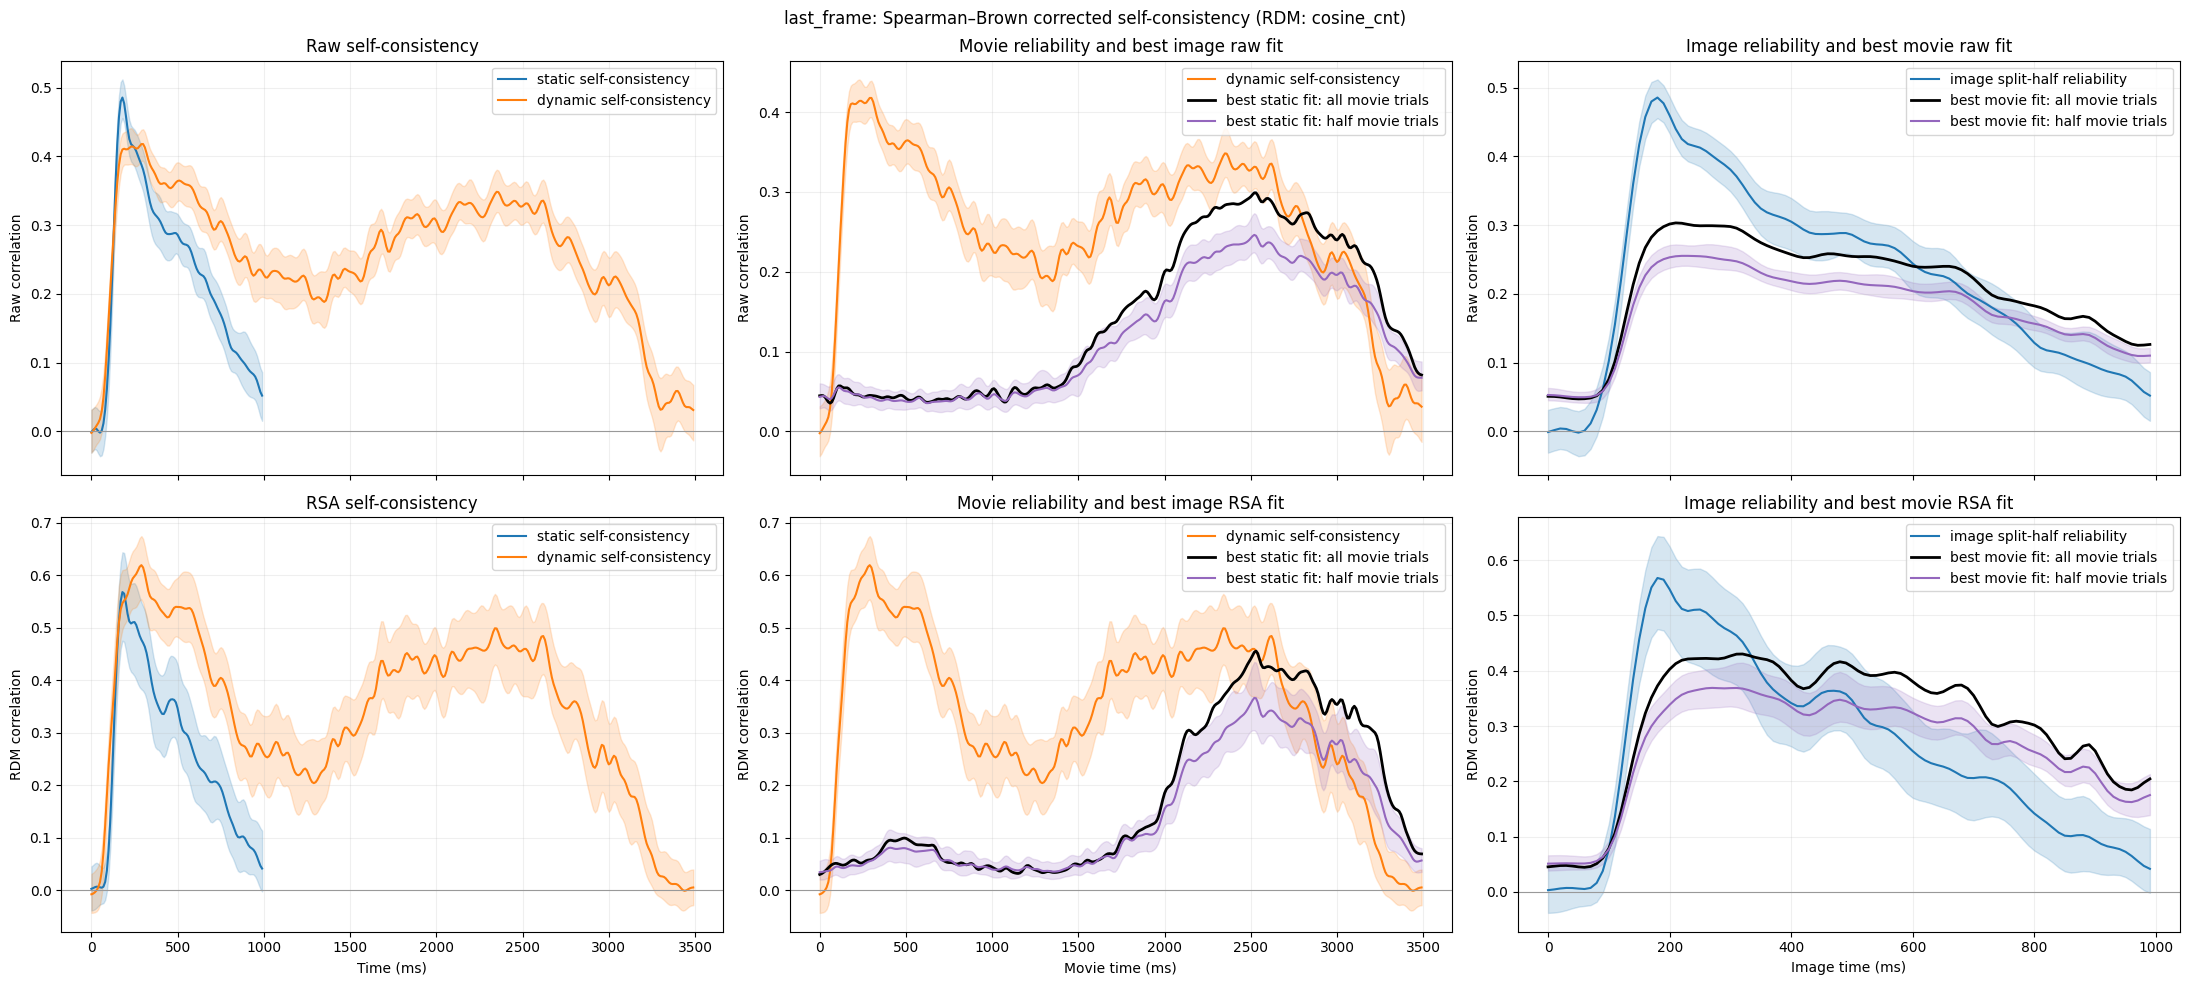

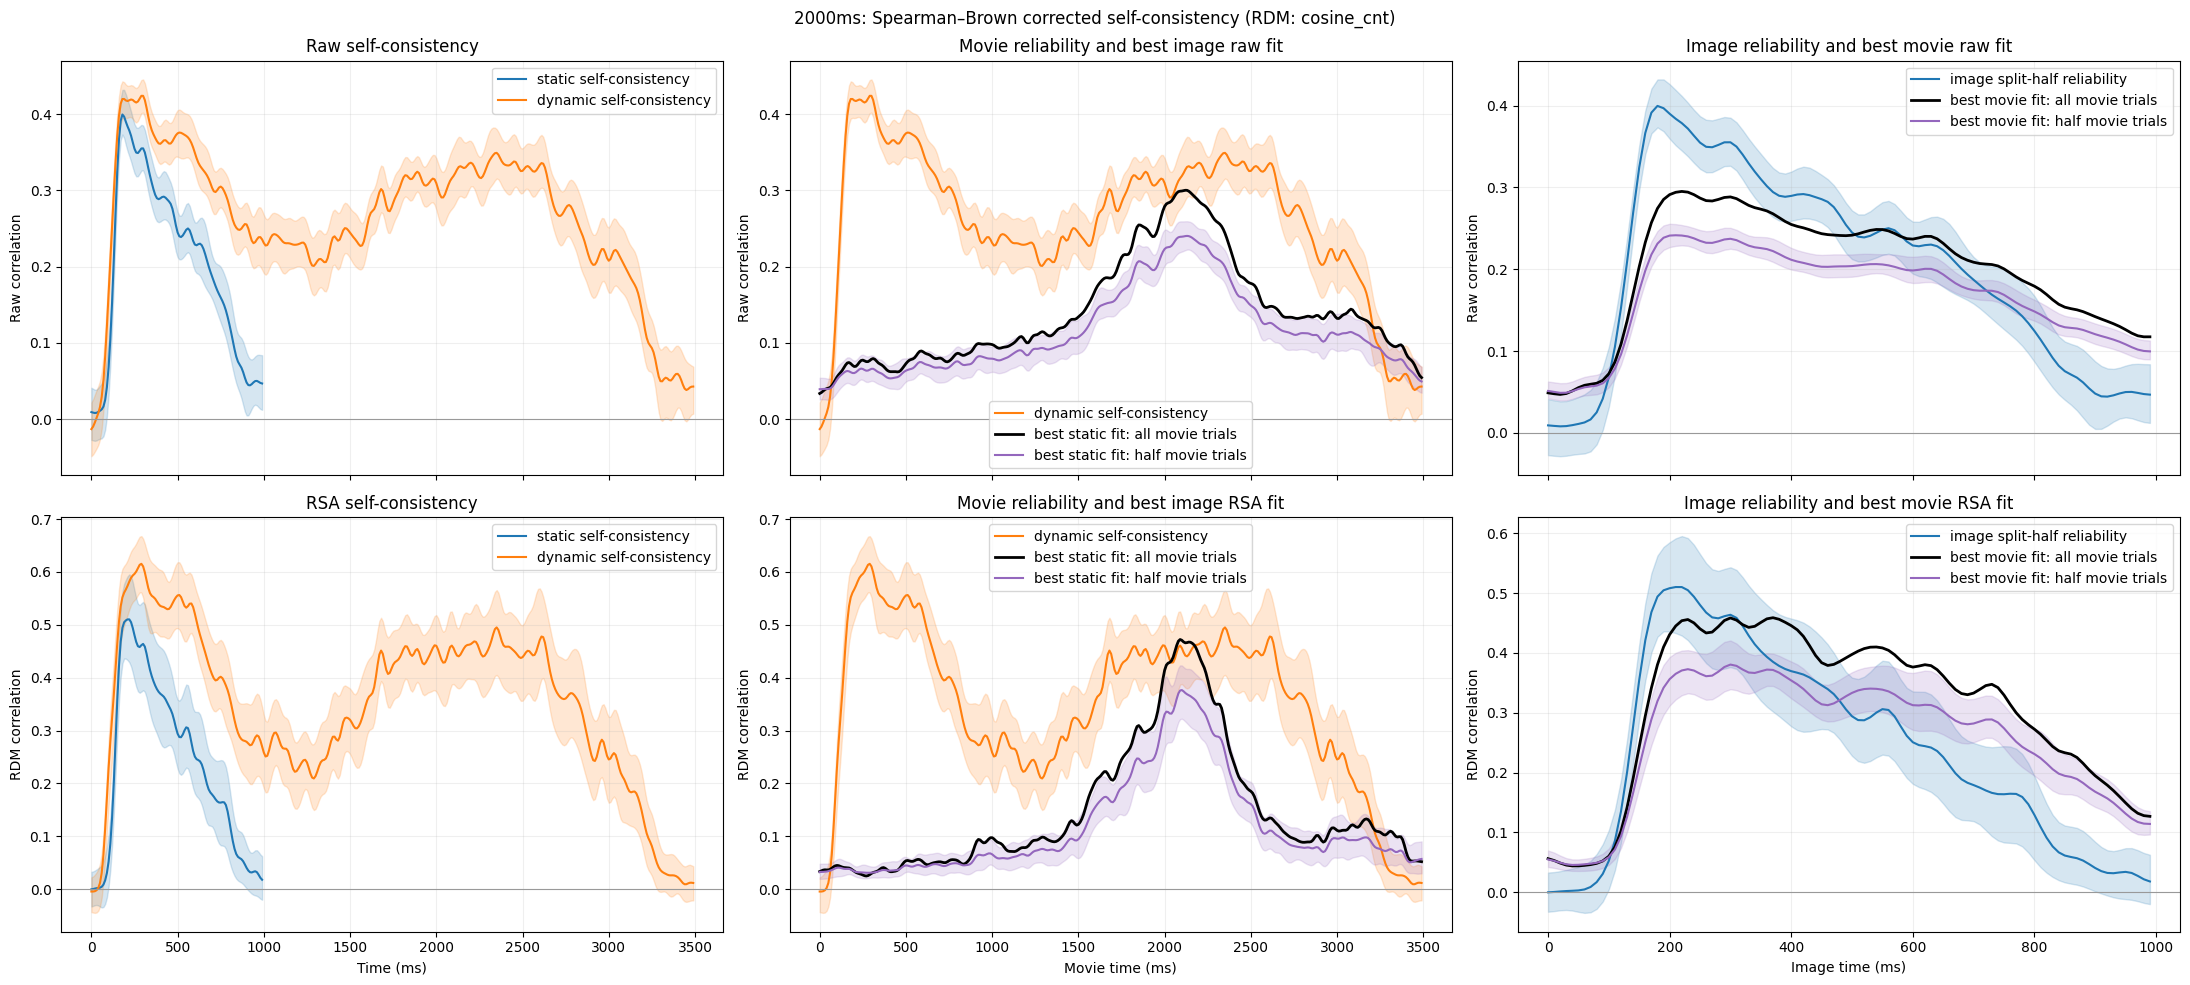

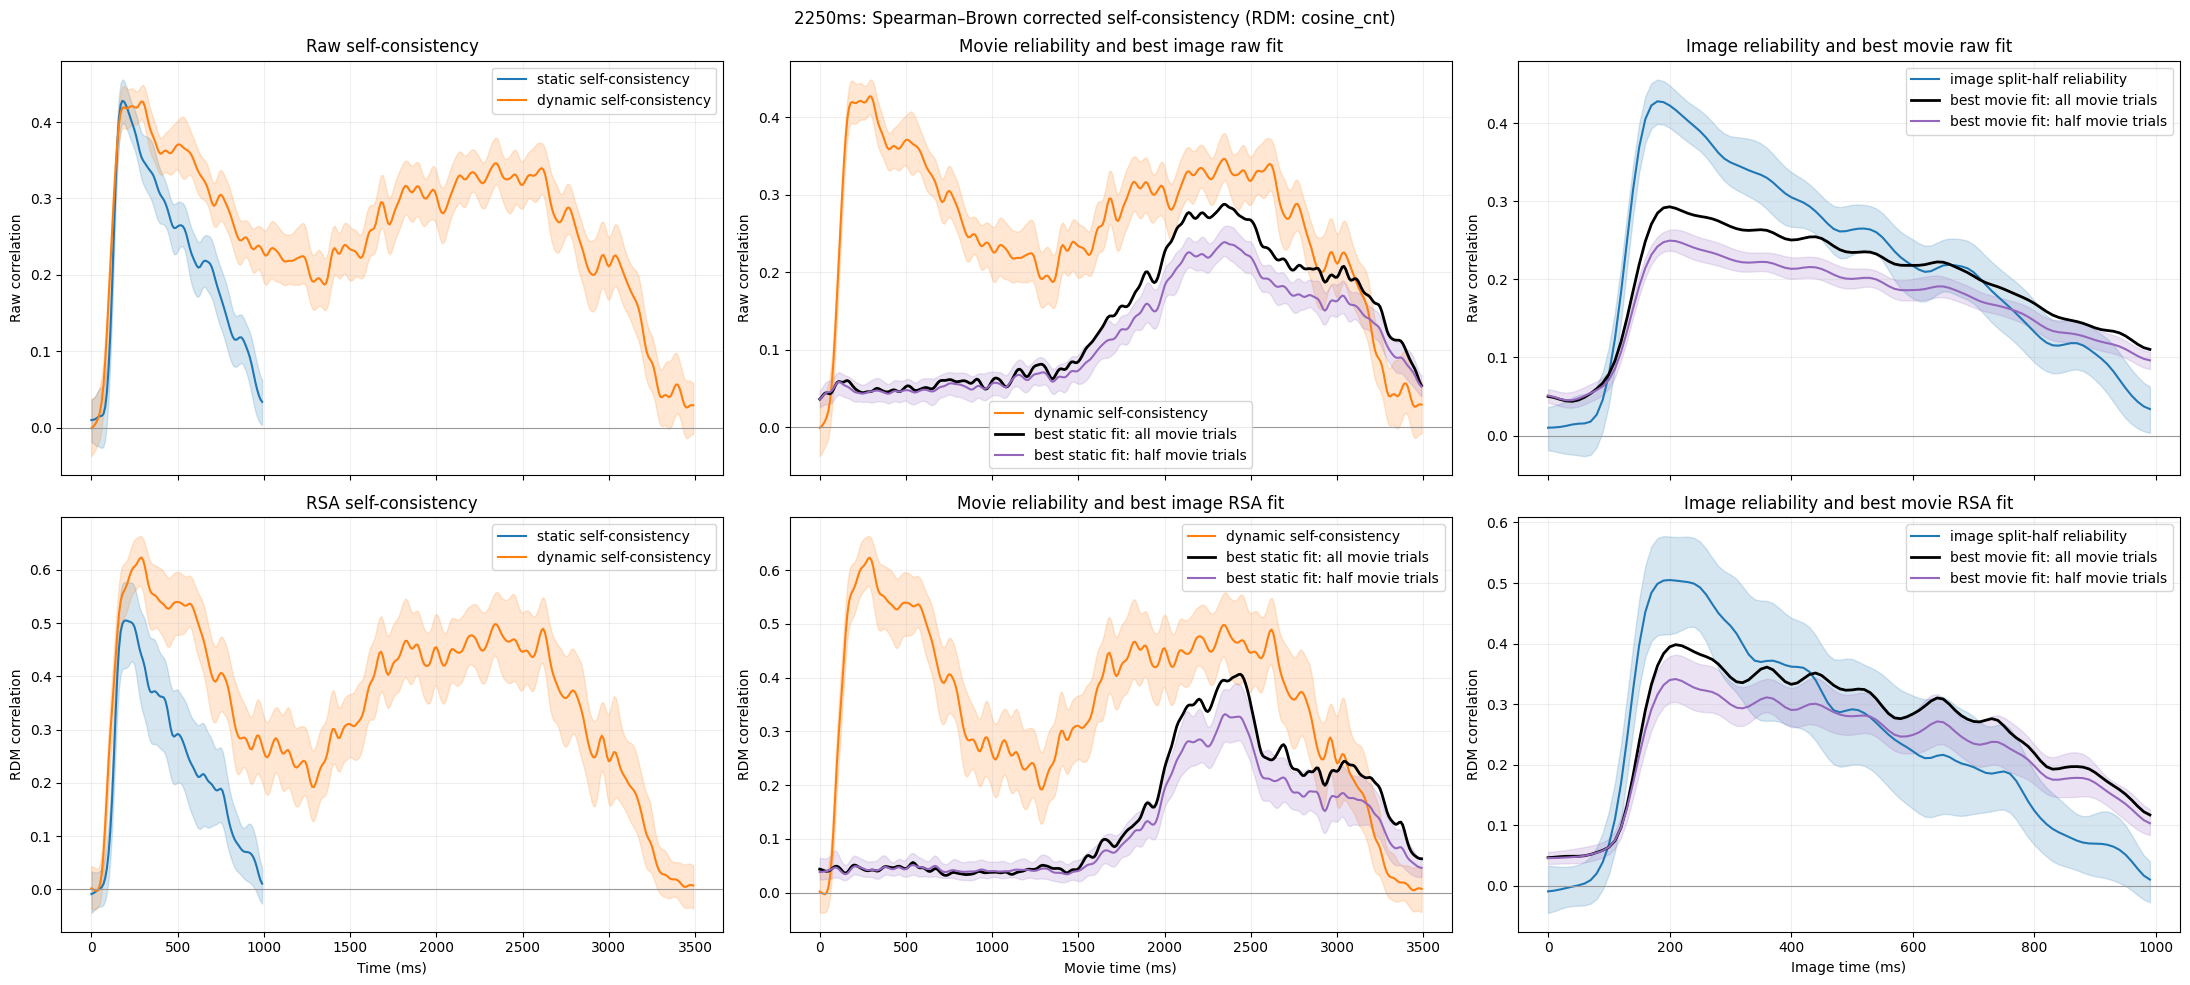

In [5]:
correction_label = (
    "Spearman–Brown corrected"
    if cfg.use_spearman_brown
    else "uncorrected"
)
for frame_timing, results in results_by_timing.items():
    static_times_ms = results["static_times_ms"]
    dynamic_times_ms = results["dynamic_times_ms"]
    figure, axes = plt.subplots(2, 3, figsize=(22, 10), sharex="col")

    for row_index, analysis_type in enumerate(("raw", "rsa")):
        for condition, color, times_ms in (
                ("static", "tab:blue", static_times_ms),
                ("dynamic", "tab:orange", dynamic_times_ms),
                ):
            summary = get_self_consistency_summary(
                results, condition, analysis_type, cfg.use_spearman_brown,
            )
            axes[row_index, 0].plot(
                times_ms,
                smooth_for_plot(summary["mean"], cfg.plot_smoothing_sigma),
                color=color,
                label=f"{condition} self-consistency",
            )
            axes[row_index, 0].fill_between(
                times_ms,
                smooth_for_plot(summary["lower"], cfg.plot_smoothing_sigma),
                smooth_for_plot(summary["upper"], cfg.plot_smoothing_sigma),
                color=color, alpha=0.18,
            )
        # end for condition

        static_summary = get_self_consistency_summary(
            results, "static", analysis_type, cfg.use_spearman_brown,
        )
        dynamic_summary = get_self_consistency_summary(
            results, "dynamic", analysis_type, cfg.use_spearman_brown,
        )
        all_key = f"{analysis_type}_lagged_correlation_all_dynamic_trials"
        half_key = f"{analysis_type}_lagged_correlation_half_dynamic_trials"
        all_best = best_static_fit(
            results[all_key], static_times_ms, cfg.static_reference_window_ms,
        )
        half_best = best_static_fit(
            results[half_key], static_times_ms, cfg.static_reference_window_ms,
        )
        all_reverse_best = best_dynamic_fit(results[all_key])
        half_reverse_best = best_dynamic_fit(results[half_key])
        axes[row_index, 1].plot(
            dynamic_times_ms,
            smooth_for_plot(
                dynamic_summary["mean"], cfg.plot_smoothing_sigma,
            ),
            color="tab:orange", label="dynamic self-consistency",
        )
        axes[row_index, 1].fill_between(
            dynamic_times_ms,
            smooth_for_plot(
                dynamic_summary["lower"], cfg.plot_smoothing_sigma,
            ),
            smooth_for_plot(
                dynamic_summary["upper"], cfg.plot_smoothing_sigma,
            ),
            color="tab:orange", alpha=0.18,
        )
        axes[row_index, 1].plot(
            dynamic_times_ms,
            smooth_for_plot(all_best, cfg.plot_smoothing_sigma),
            color="black", linewidth=2,
            label="best static fit: all movie trials",
        )
        axes[row_index, 1].plot(
            dynamic_times_ms,
            smooth_for_plot(
                np.nanmean(half_best, axis=0), cfg.plot_smoothing_sigma,
            ),
            color="tab:purple", label="best static fit: half movie trials",
        )
        axes[row_index, 1].fill_between(
            dynamic_times_ms,
            smooth_for_plot(
                np.nanpercentile(half_best, 2.5, axis=0),
                cfg.plot_smoothing_sigma,
            ),
            smooth_for_plot(
                np.nanpercentile(half_best, 97.5, axis=0),
                cfg.plot_smoothing_sigma,
            ),
            color="tab:purple", alpha=0.18,
        )
        axes[row_index, 2].plot(
            static_times_ms,
            smooth_for_plot(
                static_summary["mean"], cfg.plot_smoothing_sigma,
            ),
            color="tab:blue", label="image split-half reliability",
        )
        axes[row_index, 2].fill_between(
            static_times_ms,
            smooth_for_plot(
                static_summary["lower"], cfg.plot_smoothing_sigma,
            ),
            smooth_for_plot(
                static_summary["upper"], cfg.plot_smoothing_sigma,
            ),
            color="tab:blue", alpha=0.18,
        )
        axes[row_index, 2].plot(
            static_times_ms,
            smooth_for_plot(all_reverse_best, cfg.plot_smoothing_sigma),
            color="black", linewidth=2,
            label="best movie fit: all movie trials",
        )
        axes[row_index, 2].plot(
            static_times_ms,
            smooth_for_plot(
                np.nanmean(half_reverse_best, axis=0),
                cfg.plot_smoothing_sigma,
            ),
            color="tab:purple", label="best movie fit: half movie trials",
        )
        axes[row_index, 2].fill_between(
            static_times_ms,
            smooth_for_plot(
                np.nanpercentile(half_reverse_best, 2.5, axis=0),
                cfg.plot_smoothing_sigma,
            ),
            smooth_for_plot(
                np.nanpercentile(half_reverse_best, 97.5, axis=0),
                cfg.plot_smoothing_sigma,
            ),
            color="tab:purple", alpha=0.18,
        )
    # end for row_index, analysis_type

    axes[0, 0].set(title="Raw self-consistency", ylabel="Raw correlation")
    axes[0, 1].set(title="Movie reliability and best image raw fit", ylabel="Raw correlation")
    axes[0, 2].set(title="Image reliability and best movie raw fit", ylabel="Raw correlation")
    axes[1, 0].set(title="RSA self-consistency", xlabel="Time (ms)", ylabel="RDM correlation")
    axes[1, 1].set(title="Movie reliability and best image RSA fit", xlabel="Movie time (ms)", ylabel="RDM correlation")
    axes[1, 2].set(title="Image reliability and best movie RSA fit", xlabel="Image time (ms)", ylabel="RDM correlation")
    for axis in axes.flat:
        axis.axhline(0, color="0.6", linewidth=0.8)
        axis.grid(alpha=0.2)
        axis.legend()
    # end for axis
    figure.suptitle(
        f"{frame_timing}: {correction_label} self-consistency "
        f"(RDM: {cfg.rdm_metric})"
    )
    figure.tight_layout()
    plt.show()
# end for frame_timing

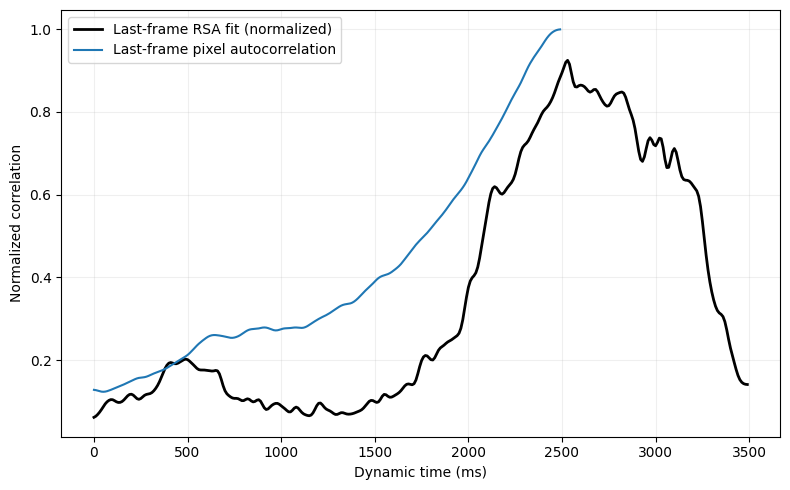

In [6]:
# Select the last-frame RSA trace explicitly instead of reusing the final loop value.
last_frame_results = results_by_timing["last_frame"]
last_frame_best = best_static_fit(
    last_frame_results["rsa_lagged_correlation_all_dynamic_trials"],
    last_frame_results["static_times_ms"],
    cfg.static_reference_window_ms,
)
last_frame_best_normalized = last_frame_best / np.nanmax(last_frame_best)

# Correlate the pixels of frame 250 with all frames preceding it.
ac_mat = np.load("/Users/tizianocausin/Desktop/pix_ac_mat.npy")
pixel_last_frame_autocorrelation = ac_mat[:250, 250]
dynamic_times_ms = last_frame_results["dynamic_times_ms"]

figure, axis = plt.subplots(figsize=(8, 5))
axis.plot(
    dynamic_times_ms,
    smooth_for_plot(last_frame_best_normalized, cfg.plot_smoothing_sigma),
    color="black", linewidth=2,
    label="Last-frame RSA fit (normalized)",
)
axis.plot(
    dynamic_times_ms[:pixel_last_frame_autocorrelation.size],
    smooth_for_plot(
        pixel_last_frame_autocorrelation, cfg.plot_smoothing_sigma,
    ),
    color="tab:blue", label="Last-frame pixel autocorrelation",
)
axis.set(xlabel="Dynamic time (ms)", ylabel="Normalized correlation")
axis.grid(alpha=0.2)
axis.legend()
figure.tight_layout()
plt.show()

## Cross-temporal matrices

Rows are dynamic timepoints and columns are static timepoints. Half-trial panels show the mean matrix over the saved half-movie repetitions.

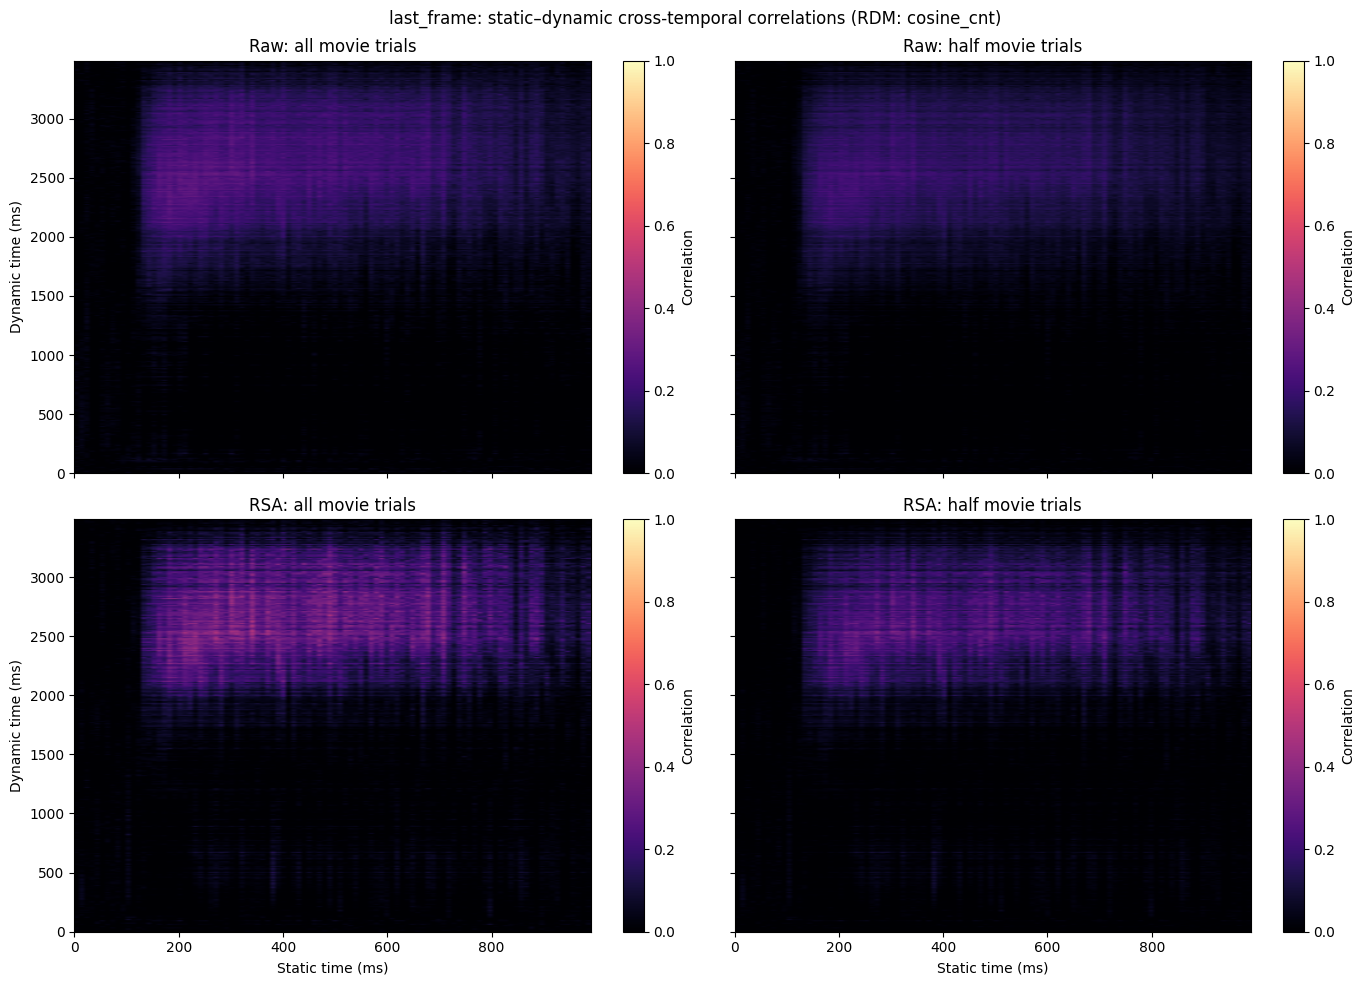

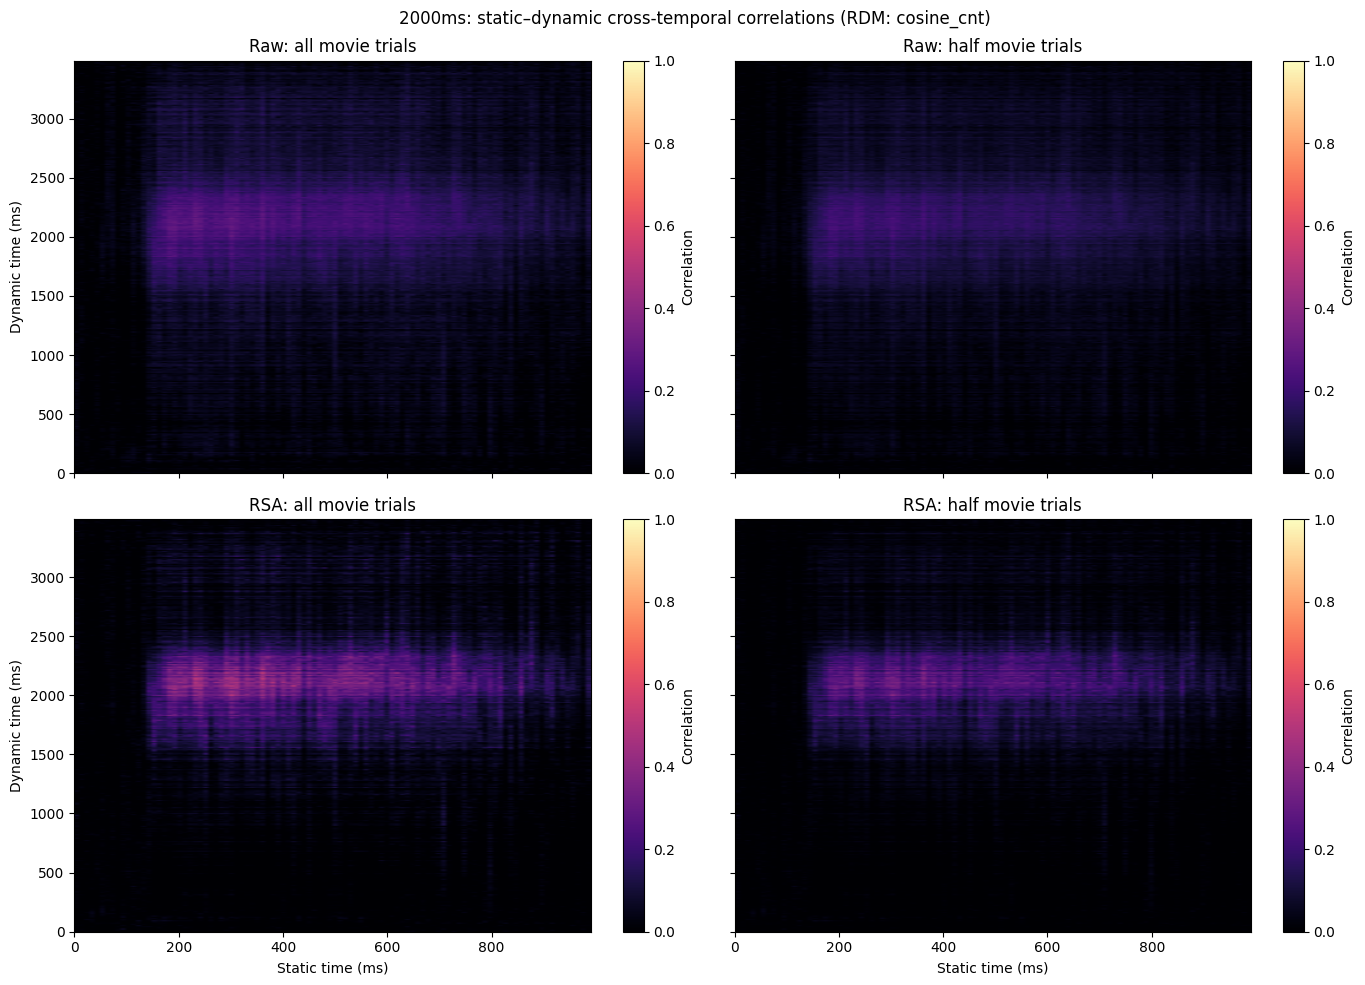

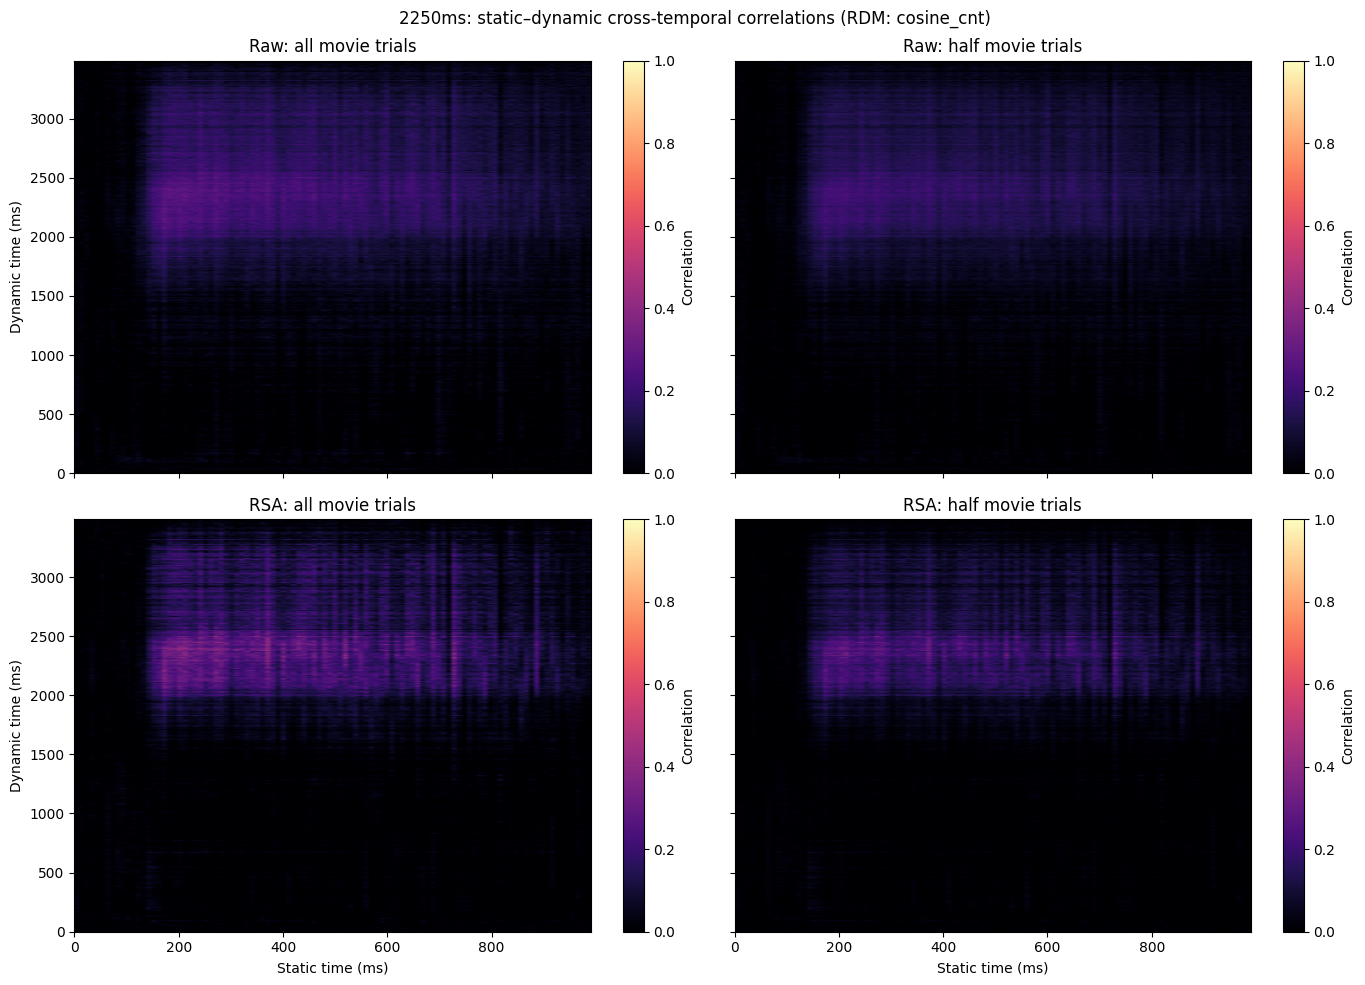

In [7]:
for frame_timing, results in results_by_timing.items():
    static_times_ms = results["static_times_ms"]
    dynamic_times_ms = results["dynamic_times_ms"]
    extent = (
        static_times_ms[0], static_times_ms[-1],
        dynamic_times_ms[0], dynamic_times_ms[-1],
    )
    matrix_specs = (
        (0, 0, results["raw_lagged_correlation_all_dynamic_trials"], "Raw: all movie trials"),
        (0, 1, np.nanmean(results["raw_lagged_correlation_half_dynamic_trials"], axis=0), "Raw: half movie trials"),
        (1, 0, results["rsa_lagged_correlation_all_dynamic_trials"], "RSA: all movie trials"),
        (1, 1, np.nanmean(results["rsa_lagged_correlation_half_dynamic_trials"], axis=0), "RSA: half movie trials"),
    )
    figure, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
    for row_index, column_index, matrix, title in matrix_specs:
        image = axes[row_index, column_index].imshow(
            matrix, origin="lower", aspect="auto", extent=extent,
            cmap="magma", vmin=cfg.matrix_vmin, vmax=cfg.matrix_vmax,
        )
        axes[row_index, column_index].set(title=title)
        figure.colorbar(image, ax=axes[row_index, column_index], label="Correlation")
    # end for matrix_specs
    for axis in axes[1]:
        axis.set_xlabel("Static time (ms)")
    # end for axis
    for axis in axes[:, 0]:
        axis.set_ylabel("Dynamic time (ms)")
    # end for axis
    figure.suptitle(
        f"{frame_timing}: static–dynamic cross-temporal correlations "
        f"(RDM: {cfg.rdm_metric})"
    )
    figure.tight_layout()
    plt.show()
# end for frame_timing

## Compare frame timings

Solid lines use all movie trials. Dashed lines use the mean over half-movie-trial repetitions. The top row selects the best image time for every movie timepoint within `cfg.static_reference_window_ms`; the bottom row reverses the calculation and selects the best movie time from the complete movie time axis for every image timepoint.

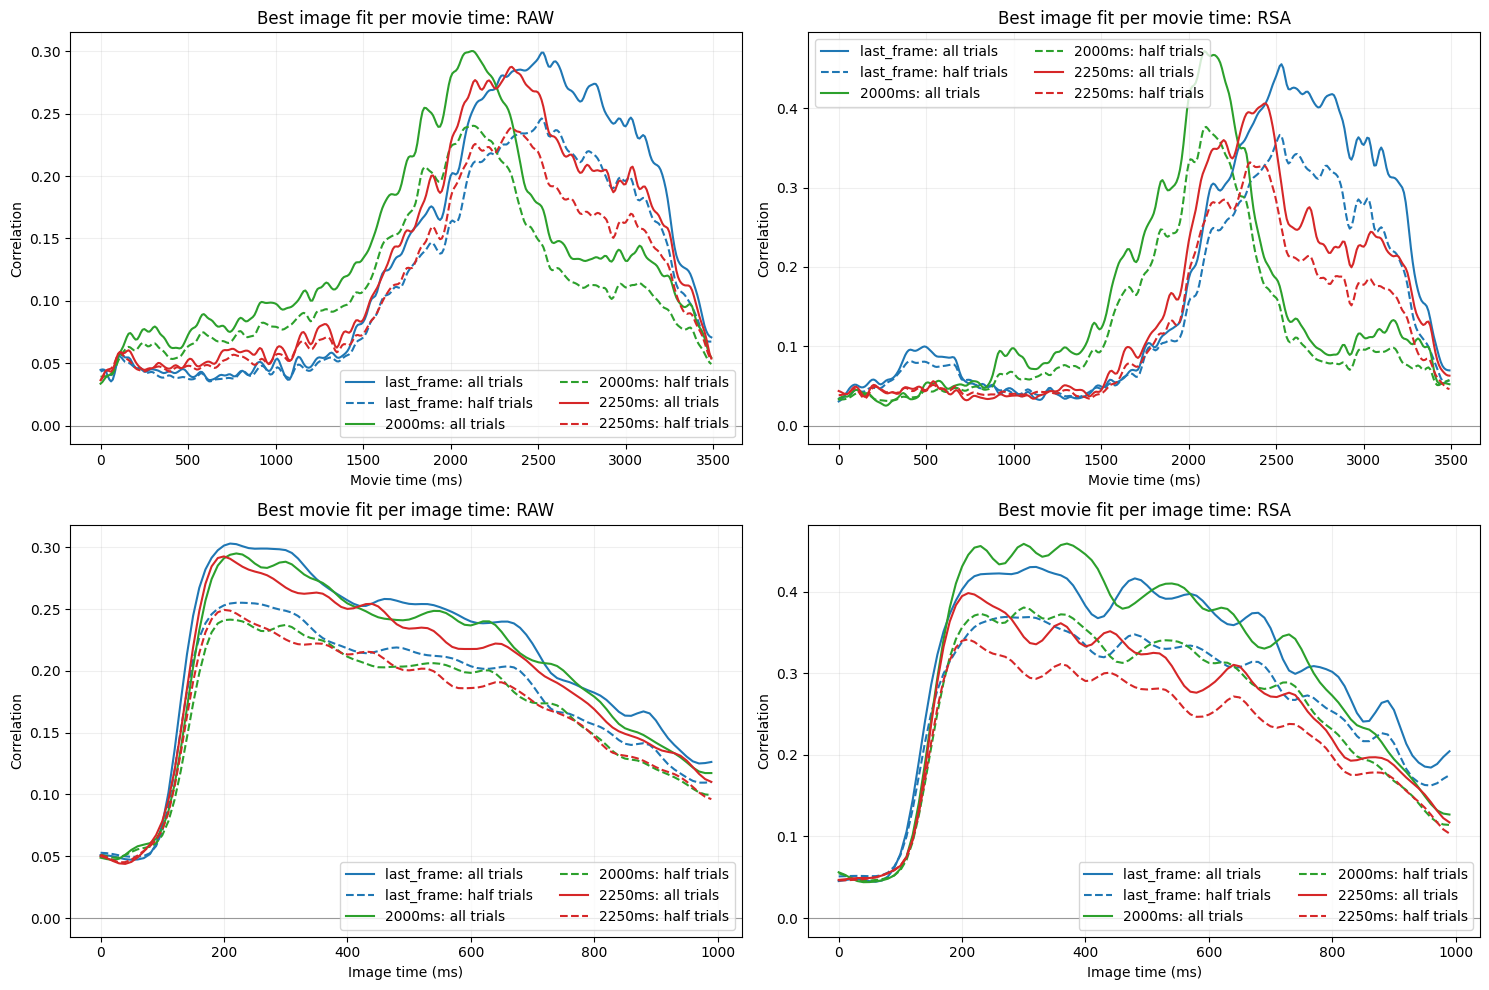

In [8]:
figure, axes = plt.subplots(2, 2, figsize=(15, 10))
timing_colors = {
    "last_frame": "tab:blue",
    "2000ms": "tab:green",
    "2250ms": "tab:red",
}
for column_index, analysis_type in enumerate(("raw", "rsa")):
    for frame_timing, results in results_by_timing.items():
        static_times_ms = results["static_times_ms"]
        dynamic_times_ms = results["dynamic_times_ms"]
        all_best = best_static_fit(
            results[f"{analysis_type}_lagged_correlation_all_dynamic_trials"],
            static_times_ms, cfg.static_reference_window_ms,
        )
        half_best = best_static_fit(
            results[f"{analysis_type}_lagged_correlation_half_dynamic_trials"],
            static_times_ms, cfg.static_reference_window_ms,
        )
        all_reverse_best = best_dynamic_fit(
            results[f"{analysis_type}_lagged_correlation_all_dynamic_trials"],
        )
        half_reverse_best = best_dynamic_fit(
            results[f"{analysis_type}_lagged_correlation_half_dynamic_trials"],
        )
        color = timing_colors.get(frame_timing)
        axes[0, column_index].plot(
            dynamic_times_ms,
            smooth_for_plot(all_best, cfg.plot_smoothing_sigma),
            color=color,
            label=f"{frame_timing}: all trials",
        )
        axes[0, column_index].plot(
            dynamic_times_ms,
            smooth_for_plot(
                np.nanmean(half_best, axis=0), cfg.plot_smoothing_sigma,
            ),
            color=color, linestyle="--",
            label=f"{frame_timing}: half trials",
        )
        axes[1, column_index].plot(
            static_times_ms,
            smooth_for_plot(all_reverse_best, cfg.plot_smoothing_sigma),
            color=color,
            label=f"{frame_timing}: all trials",
        )
        axes[1, column_index].plot(
            static_times_ms,
            smooth_for_plot(
                np.nanmean(half_reverse_best, axis=0),
                cfg.plot_smoothing_sigma,
            ),
            color=color, linestyle="--",
            label=f"{frame_timing}: half trials",
        )
    # end for frame_timing
    axes[0, column_index].set(
        title=f"Best image fit per movie time: {analysis_type.upper()}",
        xlabel="Movie time (ms)", ylabel="Correlation",
    )
    axes[1, column_index].set(
        title=f"Best movie fit per image time: {analysis_type.upper()}",
        xlabel="Image time (ms)", ylabel="Correlation",
    )
# end for column_index, analysis_type
for axis in axes.flat:
    axis.axhline(0, color="0.6", linewidth=0.8)
    axis.grid(alpha=0.2)
    axis.legend(ncol=2)
# end for axis
figure.tight_layout()
plt.show()